In [1]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from scipy.optimize import minimize
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv('team_handoff/baseline_returns.csv')

In [3]:
moex_data = pd.read_csv('imoex2025.csv', sep=';')
moex_data['Close'] = moex_data['Close'].str.replace(',', '.').astype(float)

In [4]:
moex_data['Return'] = moex_data['Close'].pct_change()
moex_data['Return'] = moex_data['Return'].fillna(0)

In [5]:
data['Date'] = pd.to_datetime(data['Date'])
moex_data['Date'] = pd.to_datetime(moex_data['Date'], format='%d.%m.%Y')

In [6]:
data = pd.merge(data, moex_data[['Date', 'Return']], on='Date')
data.rename(columns={'Return': 'MOEX'}, inplace=True)
data = data.drop(0).reset_index(drop=True)
moex_returns = data['MOEX'].values

Посчитаем исторические $\beta$

In [7]:
betas = {}
residuals = {}
columns = data.columns[1:-1]
for column in columns:
    X = data['MOEX'].values.reshape(-1, 1)
    y = data[column].values 
    
    model = LinearRegression()
    model.fit(X, y)
    
    beta = model.coef_[0]
    alpha = model.intercept_
     
    betas[column] = beta
    residuals[column] = data[column].values - beta * moex_returns - alpha

var_e = {column: np.var(residuals[column]) for column in columns}
var_moex = np.var(moex_returns)

In [8]:
cov_matrix = np.zeros((30, 30))

for i in range(30):
    for j in range(30):
        if i != j:
            cov_matrix[i, j] = betas[columns[i]] * betas[columns[j]] * var_moex
        else:
            cov_matrix[i, j] = betas[columns[i]]**2 * var_moex + var_e[columns[i]]

Ограничения

In [9]:
bounds = [(0, 1) for _ in range(30)]  # короткие продажи запрещены 
constraints = {'type': 'eq', 'fun': lambda w: np.sum(w) - 1}

Найдем минимум и максимум доходности портфеля

In [10]:
mu = data[data.columns[1:-1]].mean().values
res_min = minimize(lambda w: w.T @ mu, np.array(30 * [1./30]), bounds=bounds, constraints=constraints)
R_min = res_min.fun

res_max = minimize(lambda w: -w.T @ mu, np.array(30 * [1./30]), bounds=bounds, constraints=constraints)
R_max = -res_max.fun

Строим границу минимальной дисперсии

In [11]:
target_returns = np.linspace(R_min, R_max, 50)
st_dev = []

for target in target_returns:
    cons = [
        {'type': 'eq', 'fun': lambda w: np.sum(w) - 1},
        {'type': 'eq', 'fun': lambda w, target=target: w.T @ mu - target}
    ]
    result = minimize(lambda w: np.sqrt(w.T @ cov_matrix @ w),
                      np.array(30 * [1./30]), bounds=bounds, constraints=cons)
    st_dev.append(result.fun if result.success else np.nan)

Строим границу эффективных портфелей

In [12]:
sorted_idx = np.argsort(target_returns)
target_returns = np.array(target_returns)[sorted_idx]
st_dev = np.array(st_dev)[sorted_idx]

min_risk_idx = np.argmin(st_dev)

effective_st_dev = st_dev[min_risk_idx:]
effective_ret = target_returns[min_risk_idx:]

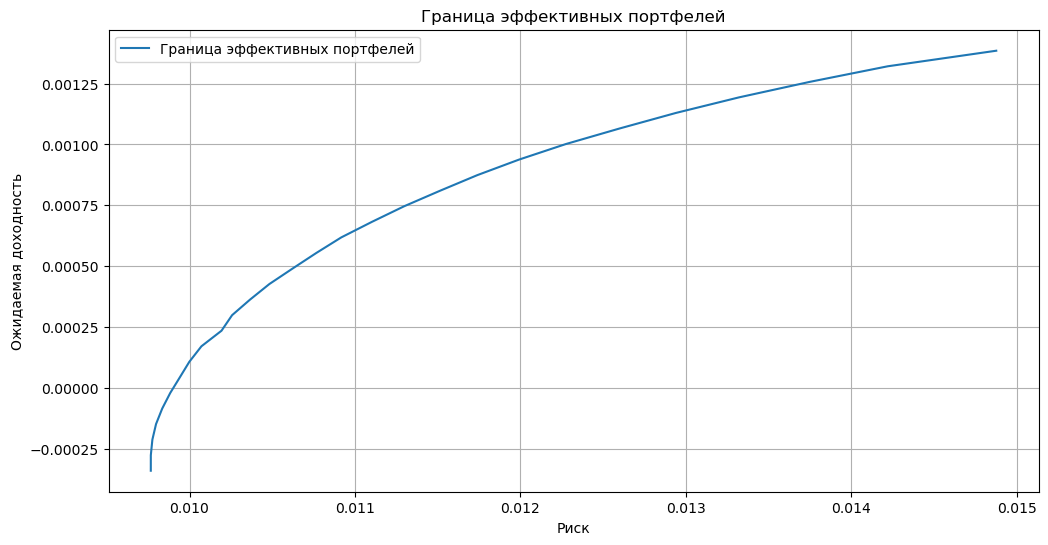

In [13]:
plt.figure(figsize=(12, 6))
plt.plot(effective_st_dev, effective_ret, label='Граница эффективных портфелей')
plt.xlabel('Риск')
plt.ylabel('Ожидаемая доходность')
plt.title('Граница эффективных портфелей')
plt.legend()
plt.grid(True)
plt.show()

In [14]:
a, b = effective_st_dev, effective_ret

Используем скорректированные $\beta$

In [15]:
betas_adjusted = {}

for ticker, beta in betas.items():
    betas_adjusted[ticker] = 0.333 + 0.667 * beta

In [16]:
cov_matrix_adjusted = np.zeros((30, 30))

for i in range(30):
    for j in range(30):
        if i != j:
            cov_matrix_adjusted[i, j] = betas_adjusted[columns[i]] * betas_adjusted[columns[j]] * var_moex
        else:
            cov_matrix_adjusted[i, j] = betas_adjusted[columns[i]]**2 * var_moex + var_e[columns[i]]

In [17]:
st_dev_adj = []

for target in target_returns:
    cons = [
        {'type': 'eq', 'fun': lambda w: np.sum(w) - 1},
        {'type': 'eq', 'fun': lambda w, target=target: w.T @ mu - target}
    ]
    result = minimize(lambda w: np.sqrt(w.T @ cov_matrix_adjusted @ w),
                      np.array(30 * [1./30]), bounds=bounds, constraints=cons)
    st_dev_adj.append(result.fun if result.success else np.nan)

In [18]:
st_dev_adj = np.array(st_dev_adj)[sorted_idx]

min_risk_idx_adj = np.argmin(st_dev_adj)

effective_st_dev_adj = st_dev_adj[min_risk_idx_adj:]
effective_ret_adj = target_returns[min_risk_idx_adj:]

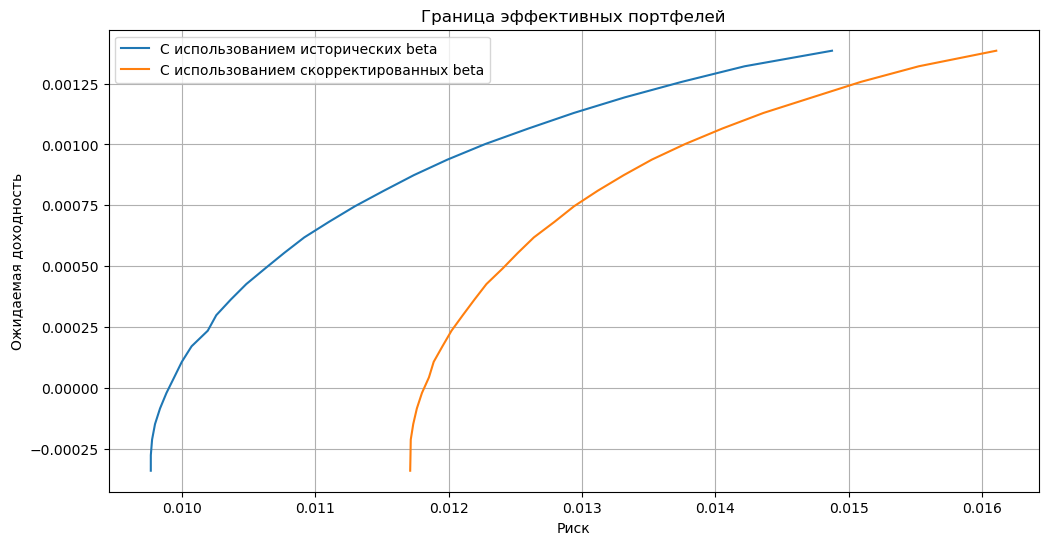

In [19]:
plt.figure(figsize=(12, 6))
plt.plot(effective_st_dev, effective_ret, label='С использованием исторических beta')
plt.plot(effective_st_dev_adj, effective_ret_adj, label='С использованием скорректированных beta')
plt.xlabel('Риск')
plt.ylabel('Ожидаемая доходность')
plt.title('Граница эффективных портфелей')
plt.legend()
plt.grid(True)
plt.show()